# Lifetime distributions

A built-in dataset of circuit breaker lifetimes.

In [1]:
from relife.datasets import load_circuit_breaker

dataset = load_circuit_breaker()
print(dataset["time"])
print(dataset["event"])
print(dataset["entry"])

[34. 28. 12. ... 42. 42. 37.]
[ True  True  True ... False False False]
[33. 27. 11. ... 31. 31. 26.]


In [2]:
from relife.lifetime_models import Weibull, Gompertz

In [3]:
weibull = Weibull()
gompertz = Gompertz()

From now, the models parameters are unknown, thus set to `np.nan`.

In [4]:
print(weibull.get_params_names())
print(weibull.get_params())

('shape', 'rate')
[nan nan]


In [5]:
weibull.fit(dataset["time"], event=dataset["event"], entry=dataset["entry"])
gompertz.fit(dataset["time"], event=dataset["event"], entry=dataset["entry"])

In [6]:
print(weibull.get_params_names(), weibull.get_params())
print(gompertz.get_params_names(), gompertz.get_params())

('shape', 'rate') [3.7267452  0.01232326]
('shape', 'rate') [0.00390781 0.07579546]


After fitting, parameters are setted inplace.

In [7]:
print(weibull.fitting_results)
print(gompertz.fitting_results)

fitted params : [3.72675, 0.0123233]
AIC           : 2493.72
AICc          : 2493.72
BIC           : 2506.41
fitted params : [0.00390781, 0.0757955]
AIC           : 2485.57
AICc          : 2485.57
BIC           : 2498.25


To plot the survival function, do the following.

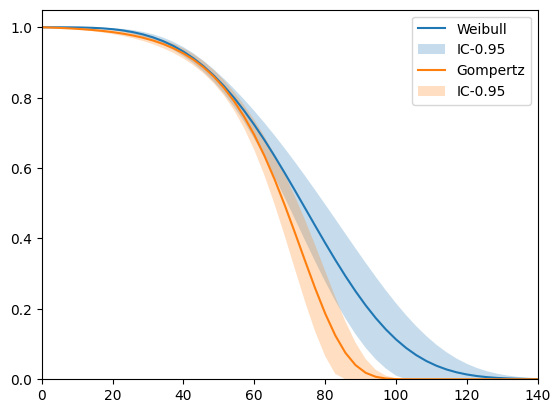

In [8]:
import numpy as np
import matplotlib.pyplot as plt

timeline = np.linspace(0, 140)
weibull.plot("sf", timeline, label="Weibull")
gompertz.plot("sf", timeline, label="Gompertz")
plt.legend()
plt.show()